# 📊 Análisis de Ventas de Retail

---

**Autor:** Jesus Gustavo Camacho Olivos  
**Fecha:** Abril 2026  
**Versión:** 1.0  

---

## 📌 1. Introducción del Proyecto

### 🎯 Objetivos del Análisis

1. **Objetivo Principal:** Identificar patrones de ventas, productos más vendidos y tendencias temporales para optimizar inventario

---

### ❓ Preguntas Clave a Responder

- ¿Cuáles son las tendencias principales en los datos?
- ¿Existen correlaciones significativas entre variables?
- ¿Qué segmentos o categorías tienen mejor desempeño?
- ¿Hay valores atípicos o anomalías que requieran atención?
- ¿Qué factores predicen mejor la variable objetivo?

---

## 📦 2. Importación de Librerías

Configuramos el entorno de trabajo con las librerías necesarias para el análisis.

In [1]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Estadística y análisis
from scipy import stats
from scipy.stats import normaltest, skew, kurtosis

# Utilidades
import warnings
from datetime import datetime, timedelta
import os

# Configuraciones generales
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Estilo de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Librerías importadas correctamente")
print(f"📌 Pandas version: {pd.__version__}")
print(f"📌 NumPy version: {np.__version__}")

✅ Librerías importadas correctamente
📌 Pandas version: 3.0.2
📌 NumPy version: 2.4.4


## 📥 3. Carga de Datos

### 📂 Opciones de Carga de Datos

A continuación se presentan diferentes métodos para cargar datos según la fuente.

In [2]:
# OPCIÓN 1: Cargar desde archivo CSV
df = pd.read_csv(
    'C:\\Users\\gusca\\OneDrive\\Documentos\\PROYECTS\\S18_PER_VENTAS_HIPERMERCADOS\\train.csv', encoding='utf-8')

print("✅ Datos cargados exitosamente")
print(
    f"📊 Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")

✅ Datos cargados exitosamente
📊 Dimensiones del dataset: 9800 filas x 18 columnas


### 👀 Vista Preliminar de los Datos

In [3]:
# Primeras filas
print("🔍 Primeras 5 filas del dataset:\n")
display(df.head())

print("\n" + "="*80 + "\n")

# Últimas filas
print("🔍 Últimas 5 filas del dataset:\n")
display(df.tail())

🔍 Primeras 5 filas del dataset:



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.00,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.00,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.00,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.00,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.00,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37




🔍 Últimas 5 filas del dataset:



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.00,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.80
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.00,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.37
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.00,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.19
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.00,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.38
9799,9800,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.00,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.38


In [4]:
# Información general del dataset
print("📋 Información General del Dataset:\n")
df.info()

print("\n" + "="*80 + "\n")

# Muestra aleatoria
print("🎲 Muestra aleatoria de 5 registros:\n")
display(df.sample(5))

📋 Información General del Dataset:

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-nul

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
3259,3260,US-2017-162103,13/11/2017,17/11/2017,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Highland Park,Illinois,60035.00,Central,OFF-BI-10000285,Office Supplies,Binders,XtraLife ClearVue Slant-D Ring Binders by Card...,3.14
5502,5503,CA-2018-127782,02/11/2018,06/11/2018,Standard Class,TH-21115,Thea Hudgings,Corporate,United States,Philadelphia,Pennsylvania,19140.00,East,FUR-FU-10001847,Furniture,Furnishings,Eldon Image Series Black Desk Accessories,3.31
6539,6540,CA-2016-109862,25/10/2016,30/10/2016,Standard Class,HK-14890,Heather Kirkland,Corporate,United States,Newark,Delaware,19711.00,East,FUR-CH-10002439,Furniture,Chairs,"Iceberg Nesting Folding Chair, 19w x 6d x 43h",291.10
5894,5895,CA-2018-100825,09/09/2018,14/09/2018,Standard Class,KD-16495,Keith Dawkins,Corporate,United States,Los Angeles,California,90036.00,West,OFF-ST-10003123,Office Supplies,Storage,Fellowes Bases and Tops For Staxonsteel/High-S...,99.87
495,496,CA-2016-134782,27/12/2016,31/12/2016,Standard Class,MD-17350,Maribeth Dona,Consumer,United States,Fayetteville,Arkansas,72701.00,South,OFF-EN-10001434,Office Supplies,Envelopes,"Strathmore #10 Envelopes, Ultimate White",105.42


## 🧹 4. Limpieza y Preparación de Datos

### 🔍 Análisis de Calidad de Datos

In [5]:
# Resumen de calidad de datos
def analizar_calidad_datos(df):
    """
    Genera un reporte completo de la calidad de los datos
    """
    calidad = pd.DataFrame({
        'Tipo_Dato': df.dtypes,
        'Valores_Nulos': df.isnull().sum(),
        '%_Nulos': (df.isnull().sum() / len(df)) * 100,
        'Valores_Únicos': df.nunique(),
        'Duplicados': df.duplicated().sum()
    })

    return calidad.sort_values('%_Nulos', ascending=False)


print("📊 Reporte de Calidad de Datos:\n")
reporte_calidad = analizar_calidad_datos(df)
display(reporte_calidad)

print(f"\n⚠️ Total de filas duplicadas: {df.duplicated().sum()}")
print(
    f"✅ Porcentaje de completitud general: {((1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100):.2f}%")

📊 Reporte de Calidad de Datos:



,Tipo_Dato,Valores_Nulos,%_Nulos,Valores_Únicos,Duplicados
Postal Code,float64,11,0.11,626,0
Row ID,int64,0,0.00,9800,0
Order ID,str,0,0.00,4922,0
Order Date,str,0,0.00,1230,0
Ship Mode,str,0,0.00,4,0
Ship Date,str,0,0.00,1326,0
Customer Name,str,0,0.00,793,0
Segment,str,0,0.00,3,0
Country,str,0,0.00,1,0
Customer ID,str,0,0.00,793,0



⚠️ Total de filas duplicadas: 0
✅ Porcentaje de completitud general: 99.99%


### 🧼 Manejo de Valores Nulos

In [6]:
# Estrategias para valores nulos
print("🔧 Aplicando estrategias para valores nulos...\n")

# Opción 1: Eliminar filas con valores nulos (si son pocas)
# df_clean = df.dropna()

# Opción 2: Rellenar con mediana/media para variables numéricas
columnas_numericas = df.select_dtypes(include=[np.number]).columns
for col in columnas_numericas:
    if df[col].isnull().sum() > 0:
        mediana = df[col].median()
        df[col].fillna(mediana, inplace=True)
        print(
            f"✅ Columna '{col}': {df[col].isnull().sum()} nulos rellenados con mediana ({mediana:.2f})")

# Opción 3: Rellenar con moda para variables categóricas
columnas_categoricas = df.select_dtypes(include=['object']).columns
for col in columnas_categoricas:
    if df[col].isnull().sum() > 0:
        moda = df[col].mode()[0]
        df[col].fillna(moda, inplace=True)
        print(
            f"✅ Columna '{col}': {df[col].isnull().sum()} nulos rellenados con moda ('{moda}')")

print(f"\n✨ Valores nulos restantes: {df.isnull().sum().sum()}")

🔧 Aplicando estrategias para valores nulos...

✅ Columna 'Postal Code': 11 nulos rellenados con mediana (58103.00)

✨ Valores nulos restantes: 11


### 🗑️ Eliminación de Duplicados

In [7]:
# Identificar y eliminar duplicados
print(f"🔍 Filas duplicadas encontradas: {df.duplicated().sum()}")

if df.duplicated().sum() > 0:
    df_before = len(df)
    df = df.drop_duplicates()
    df_after = len(df)
    print(f"✅ Se eliminaron {df_before - df_after} filas duplicadas")
else:
    print("✅ No se encontraron duplicados")

print(f"\n📊 Dimensiones actuales: {df.shape}")

🔍 Filas duplicadas encontradas: 0
✅ No se encontraron duplicados

📊 Dimensiones actuales: (9800, 18)


### 🔄 Conversión de Tipos de Datos

In [8]:
# Convertir tipos de datos según sea necesario
print("🔄 Ajustando tipos de datos...\n")

# Convertir fechas si existen
if 'fecha' in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'])
    print("✅ Columna 'fecha' convertida a datetime")

# Convertir categorías para optimizar memoria
for col in columnas_categoricas:
    if df[col].nunique() / len(df) < 0.5:  # Si tiene menos del 50% de valores únicos
        df[col] = df[col].astype('category')
        print(f"✅ Columna '{col}' convertida a tipo category")

print("\n📋 Tipos de datos actualizados:")
print(df.dtypes)

🔄 Ajustando tipos de datos...



✅ Columna 'Order Date' convertida a tipo category
✅ Columna 'Ship Date' convertida a tipo category
✅ Columna 'Ship Mode' convertida a tipo category
✅ Columna 'Customer ID' convertida a tipo category
✅ Columna 'Customer Name' convertida a tipo category
✅ Columna 'Segment' convertida a tipo category
✅ Columna 'Country' convertida a tipo category
✅ Columna 'City' convertida a tipo category
✅ Columna 'State' convertida a tipo category
✅ Columna 'Region' convertida a tipo category
✅ Columna 'Product ID' convertida a tipo category
✅ Columna 'Category' convertida a tipo category
✅ Columna 'Sub-Category' convertida a tipo category
✅ Columna 'Product Name' convertida a tipo category

📋 Tipos de datos actualizados:
Row ID              int64
Order ID              str
Order Date       category
Ship Date        category
Ship Mode        category
Customer ID      category
Customer Name    category
Segment          category
Country          category
City             category
State            category

### 🎯 Detección y Tratamiento de Outliers

In [9]:
def detectar_outliers_iqr(df, columna):
    """
    Detecta outliers usando el método IQR (Rango Intercuartílico)
    """
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[columna] < limite_inferior) |
                  (df[columna] > limite_superior)]

    return outliers, limite_inferior, limite_superior


# Analizar outliers en variables numéricas principales
print("🔍 Análisis de Outliers:\n")

for col in ['ventas', 'cantidad', 'precio_unitario']:
    if col in df.columns:
        outliers, lim_inf, lim_sup = detectar_outliers_iqr(df, col)
        print(f"📊 {col}:")
        print(
            f"   • Outliers detectados: {len(outliers)} ({(len(outliers)/len(df)*100):.2f}%)")
        print(f"   • Rango normal: [{lim_inf:.2f}, {lim_sup:.2f}]")
        print()

# Decidir estrategia: eliminar, winsorizar o mantener
# Opción 1: Eliminar outliers extremos
# df = df[~df.index.isin(outliers.index)]

# Opción 2: Winsorización (reemplazar outliers con límites)
# df[col] = df[col].clip(lower=limite_inferior, upper=limite_superior)

print("✅ Análisis de outliers completado")

🔍 Análisis de Outliers:

✅ Análisis de outliers completado


### ➕ Creación de Variables Derivadas

In [10]:
# Crear variables útiles para el análisis
print("➕ Creando variables derivadas...\n")

# Ejemplo: Variables temporales
if 'fecha' in df.columns:
    df['año'] = df['fecha'].dt.year
    df['mes'] = df['fecha'].dt.month
    df['trimestre'] = df['fecha'].dt.quarter
    df['dia_semana'] = df['fecha'].dt.dayofweek
    df['nombre_mes'] = df['fecha'].dt.month_name()
    print("✅ Variables temporales creadas: año, mes, trimestre, día_semana")

# Ejemplo: Calcular ingresos totales
if 'cantidad' in df.columns and 'precio_unitario' in df.columns:
    df['ingresos_totales'] = df['cantidad'] * df['precio_unitario']
    print("✅ Variable 'ingresos_totales' creada")

# Ejemplo: Categorización
if 'Sales' in df.columns:
    df['categoria_ventas'] = pd.cut(df['Sales'],
                                    bins=[0, 3000, 5000, 10000],
                                    labels=['Bajas', 'Medias', 'Altas'])
    print("✅ Variable 'categoria_ventas' creada")

print(f"\n📊 Nuevas dimensiones del dataset: {df.shape}")

➕ Creando variables derivadas...

✅ Variable 'categoria_ventas' creada

📊 Nuevas dimensiones del dataset: (9800, 19)


## 🔍 5. Análisis Exploratorio de Datos (EDA)

### 📈 Estadísticas Descriptivas Generales

In [11]:
# Estadísticas descriptivas completas
print("📊 ESTADÍSTICAS DESCRIPTIVAS - Variables Numéricas\n")
print("="*80)

estadisticas = df.describe().T
# Coeficiente de variación
estadisticas['cv'] = (estadisticas['std'] / estadisticas['mean']) * 100
estadisticas['rango'] = estadisticas['max'] - estadisticas['min']

display(estadisticas)

print("\n" + "="*80)
print("📊 ESTADÍSTICAS DESCRIPTIVAS - Variables Categóricas\n")
display(df.describe(include=['object', 'category']))

📊 ESTADÍSTICAS DESCRIPTIVAS - Variables Numéricas



,count,mean,std,min,25%,50%,75%,max,cv,rango
Row ID,9800.00,4900.50,2829.16,1.00,2450.75,4900.50,7350.25,9800.00,57.73,9799.00
Postal Code,9789.00,55273.32,32041.22,1040.00,23223.00,58103.00,90008.00,99301.00,57.97,98261.00
Sales,9800.00,230.77,626.65,0.44,17.25,54.49,210.61,22638.48,271.55,22638.04



📊 ESTADÍSTICAS DESCRIPTIVAS - Variables Categóricas



,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,categoria_ventas
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9795
unique,4922,1230,1326,4,793,793,3,1,529,49,4,1861,3,17,1849,3
top,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,Bajas
freq,14,38,34,5859,35,35,5101,9800,891,1946,3140,19,5909,1492,47,9738


### 📊 Análisis de Distribución de Variables Numéricas


📊 Análisis de Distribución: Sales

Media: 230.77
Mediana: 54.49
Moda: 12.96
Desviación Estándar: 626.65
Asimetría (Skewness): 12.98
Curtosis: 304.29


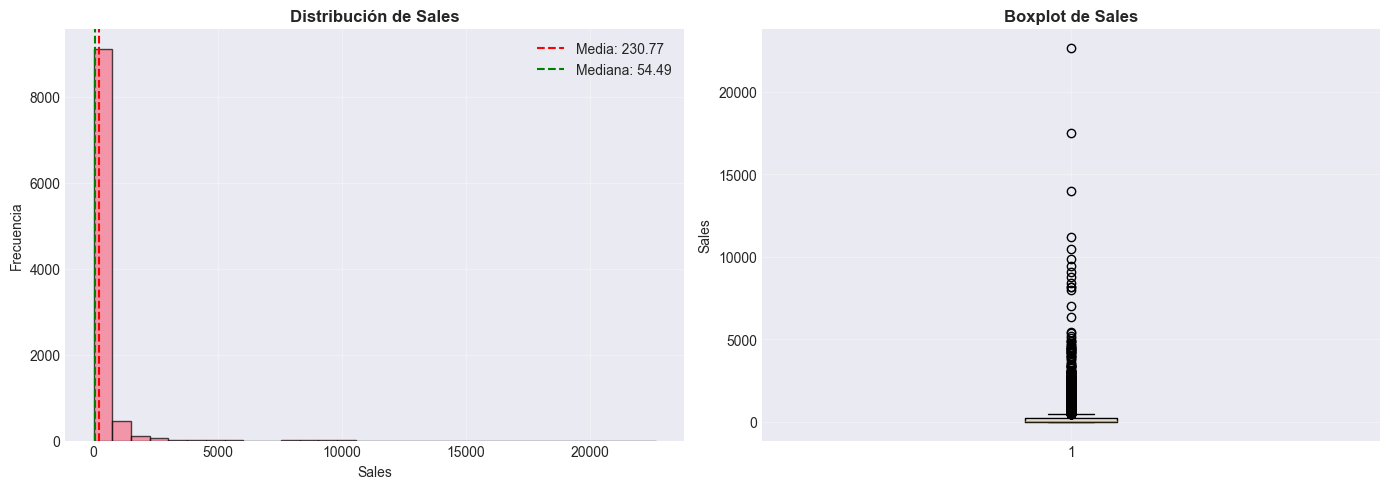

In [12]:
# Análisis de distribución con histogramas y estadísticas
def analizar_distribucion(df, columna):
    """
    Analiza la distribución de una variable numérica
    """
    print(f"\n{'='*60}")
    print(f"📊 Análisis de Distribución: {columna}")
    print(f"{'='*60}\n")

    # Estadísticas
    print(f"Media: {df[columna].mean():.2f}")
    print(f"Mediana: {df[columna].median():.2f}")
    print(f"Moda: {df[columna].mode()[0]:.2f}")
    print(f"Desviación Estándar: {df[columna].std():.2f}")
    print(f"Asimetría (Skewness): {skew(df[columna].dropna()):.2f}")
    print(f"Curtosis: {kurtosis(df[columna].dropna()):.2f}")

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma
    axes[0].hist(df[columna].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0].axvline(df[columna].mean(), color='red',
                    linestyle='--', label=f'Media: {df[columna].mean():.2f}')
    axes[0].axvline(df[columna].median(), color='green',
                    linestyle='--', label=f'Mediana: {df[columna].median():.2f}')
    axes[0].set_title(
        f'Distribución de {columna}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(columna)
    axes[0].set_ylabel('Frecuencia')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Boxplot
    axes[1].boxplot(df[columna].dropna(), vert=True)
    axes[1].set_title(f'Boxplot de {columna}', fontsize=12, fontweight='bold')
    axes[1].set_ylabel(columna)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Analizar variables clave
for col in ['Sales', 'cantidad', 'precio_unitario']:
    if col in df.columns:
        analizar_distribucion(df, col)

### 🔗 Análisis de Correlaciones

🔗 MATRIZ DE CORRELACIÓN



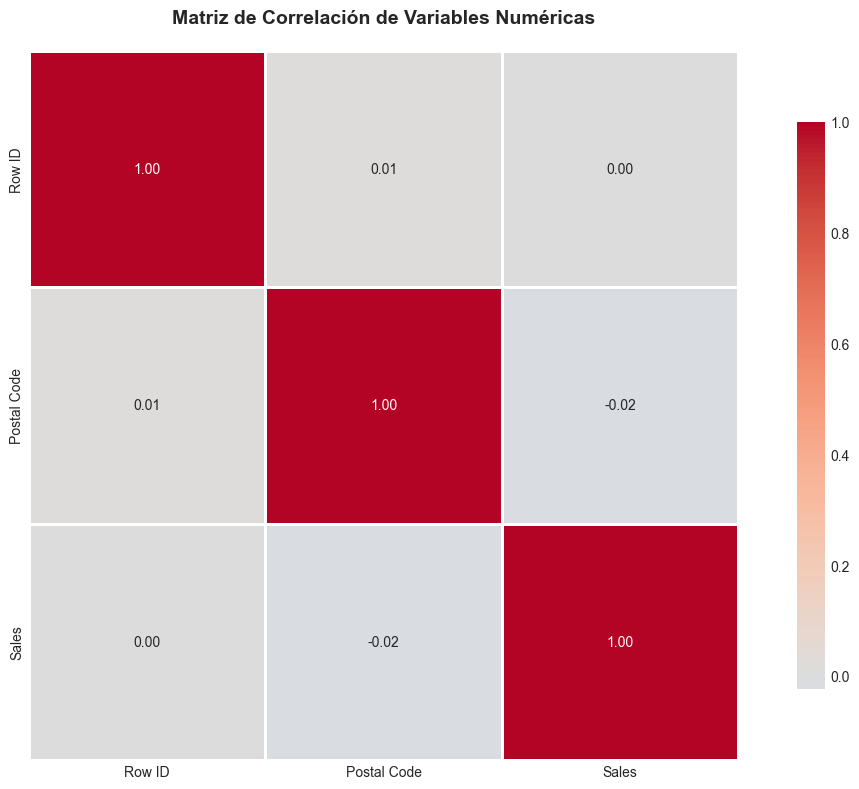


🔍 Correlaciones más fuertes (|r| > 0.5):

No se encontraron correlaciones fuertes (|r| > 0.5)


In [13]:
# Matriz de correlación
print("🔗 MATRIZ DE CORRELACIÓN\n")

# Seleccionar solo variables numéricas
df_numeric = df.select_dtypes(include=[np.number])

# Calcular correlaciones
correlacion = df_numeric.corr()

# Visualización con heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlacion,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación de Variables Numéricas',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identificar correlaciones fuertes
print("\n🔍 Correlaciones más fuertes (|r| > 0.5):\n")
correlaciones_fuertes = []
for i in range(len(correlacion.columns)):
    for j in range(i+1, len(correlacion.columns)):
        if abs(correlacion.iloc[i, j]) > 0.5:
            correlaciones_fuertes.append({
                'Variable 1': correlacion.columns[i],
                'Variable 2': correlacion.columns[j],
                'Correlación': correlacion.iloc[i, j]
            })

if correlaciones_fuertes:
    df_corr_fuertes = pd.DataFrame(correlaciones_fuertes).sort_values(
        'Correlación', ascending=False)
    display(df_corr_fuertes)
else:
    print("No se encontraron correlaciones fuertes (|r| > 0.5)")

### 📊 Análisis Univariado - Variables Categóricas


📊 Análisis de: Region



,Frecuencia,Porcentaje
Region,,
West,3140,32.04
East,2785,28.42
Central,2277,23.23
South,1598,16.31


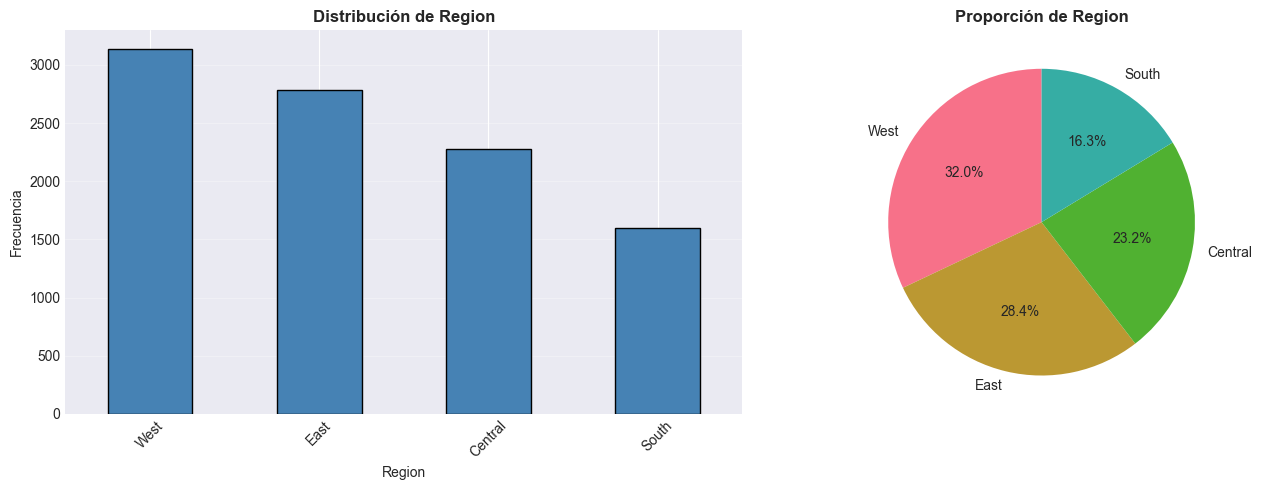


📊 Análisis de: Category



,Frecuencia,Porcentaje
Category,,
Office Supplies,5909,60.30
Furniture,2078,21.20
Technology,1813,18.50


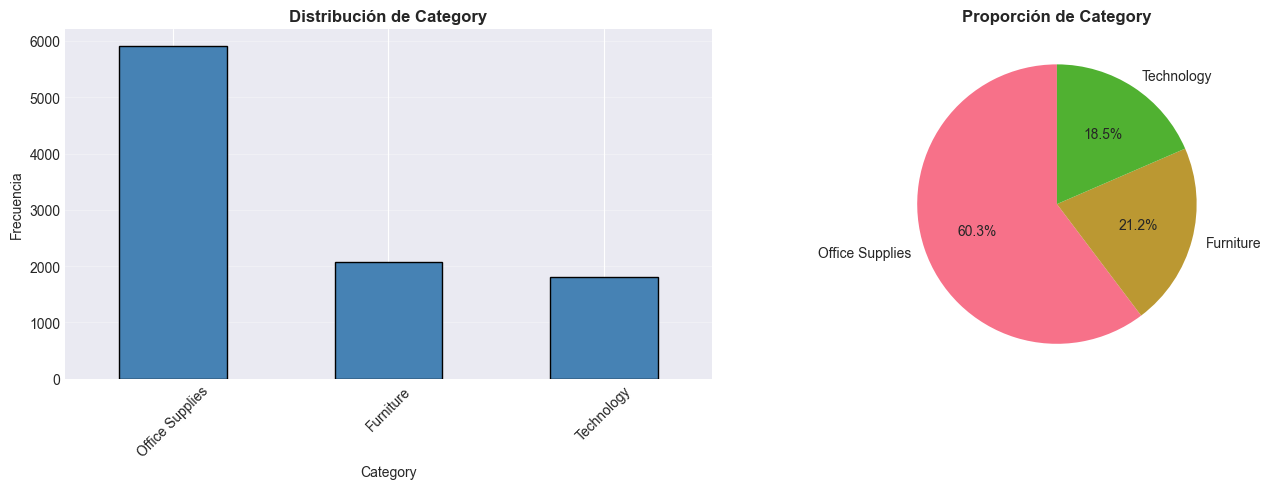

In [14]:
# Análisis de frecuencias de variables categóricas
def analizar_categorica(df, columna):
    """
    Analiza la distribución de una variable categórica
    """
    print(f"\n{'='*60}")
    print(f"📊 Análisis de: {columna}")
    print(f"{'='*60}\n")

    # Tabla de frecuencias
    freq_table = pd.DataFrame({
        'Frecuencia': df[columna].value_counts(),
        'Porcentaje': (df[columna].value_counts(normalize=True) * 100).round(2)
    })
    display(freq_table)

    # Gráfico de barras
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico de barras
    freq_table['Frecuencia'].plot(
        kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title(
        f'Distribución de {columna}', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Frecuencia')
    axes[0].set_xlabel(columna)
    axes[0].grid(True, alpha=0.3, axis='y')
    axes[0].tick_params(axis='x', rotation=45)

    # Gráfico de pastel
    axes[1].pie(freq_table['Frecuencia'],
                labels=freq_table.index,
                autopct='%1.1f%%',
                startangle=90)
    axes[1].set_title(f'Proporción de {columna}',
                      fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()


# Analizar variables categóricas principales
for col in ['Region', 'Category']:
    if col in df.columns:
        analizar_categorica(df, col)

### 🔄 Análisis Bivariado - Relaciones entre Variables

🔍 ANÁLISIS BIVARIADO

📊 Estadísticas de Ventas por Región:



,Media,Mediana,Desv_Est,Mínimo,Máximo,Cantidad
Region,,,,,,
South,243.52,54.11,779.85,1.17,22638.48,1598
East,240.40,54.96,626.37,0.85,11199.97,2785
West,226.18,61.00,524.24,0.99,13999.96,3140
Central,216.36,45.92,636.04,0.44,17499.95,2277


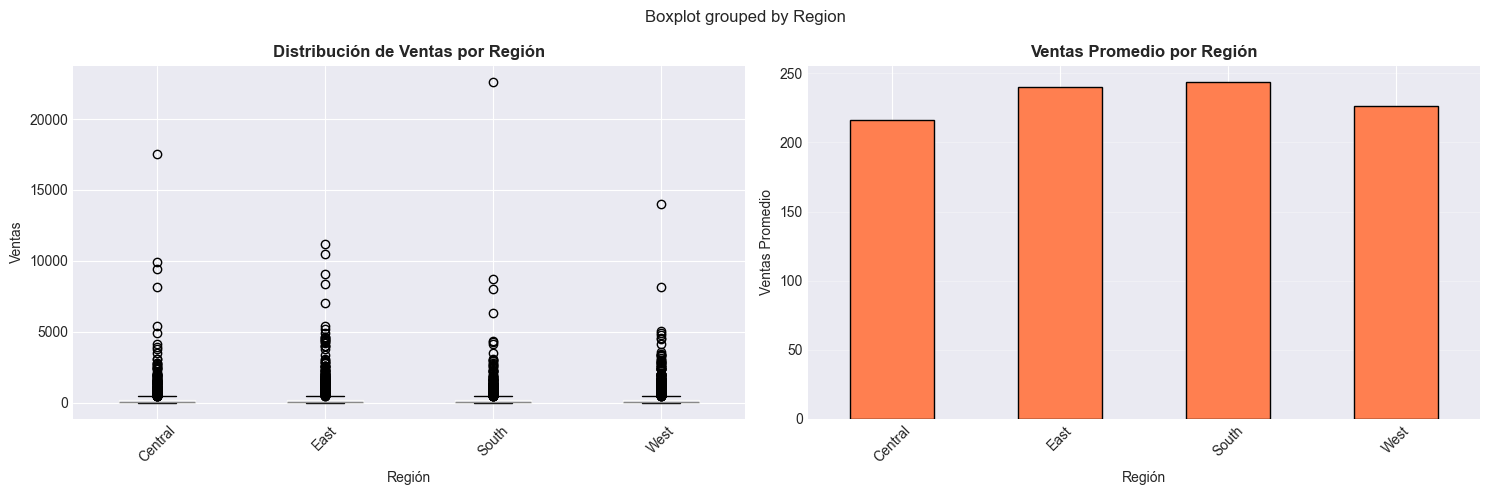

In [15]:
# Análisis de relación entre variables numéricas y categóricas
print("🔍 ANÁLISIS BIVARIADO\n")

# Ejemplo: Ventas por región
if 'Sales' in df.columns and 'Region' in df.columns:
    print("📊 Estadísticas de Ventas por Región:\n")
    ventas_region = df.groupby('Region')['Sales'].agg(
        ['mean', 'median', 'std', 'min', 'max', 'count'])
    ventas_region.columns = ['Media', 'Mediana',
                             'Desv_Est', 'Mínimo', 'Máximo', 'Cantidad']
    display(ventas_region.sort_values('Media', ascending=False))

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Boxplot por región
    df.boxplot(column='Sales', by='Region', ax=axes[0])
    axes[0].set_title('Distribución de Ventas por Región',
                      fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Región')
    axes[0].set_ylabel('Ventas')
    plt.sca(axes[0])
    plt.xticks(rotation=45)

    # Gráfico de barras con media
    ventas_region['Media'].plot(
        kind='bar', ax=axes[1], color='coral', edgecolor='black')
    axes[1].set_title('Ventas Promedio por Región',
                      fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Ventas Promedio')
    axes[1].set_xlabel('Región')
    axes[1].grid(True, alpha=0.3, axis='y')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

In [16]:
# Scatter plot para relaciones entre dos variables numéricas
if 'cantidad' in df.columns and 'ingresos_totales' in df.columns:
    plt.figure(figsize=(10, 6))
    plt.scatter(df['cantidad'], df['ingresos_totales'],
                alpha=0.5, edgecolors='black')
    plt.title('Relación entre Cantidad e Ingresos Totales',
              fontsize=14, fontweight='bold')
    plt.xlabel('Cantidad')
    plt.ylabel('Ingresos Totales')
    plt.grid(True, alpha=0.3)

    # Línea de tendencia
    z = np.polyfit(df['cantidad'].dropna(), df['ingresos_totales'].dropna(), 1)
    p = np.poly1d(z)
    plt.plot(df['cantidad'], p(df['cantidad']),
             "r--", alpha=0.8, label='Tendencia')
    plt.legend()

    plt.tight_layout()
    plt.show()

### 📅 Análisis Temporal (si aplica)

In [17]:
# Análisis de series temporales
if 'fecha' in df.columns and 'ventas' in df.columns:
    print("📅 ANÁLISIS TEMPORAL DE VENTAS\n")

    # Agrupar por mes
    df_temporal = df.groupby(df['fecha'].dt.to_period('M'))[
        'ventas'].agg(['sum', 'mean', 'count'])
    df_temporal.index = df_temporal.index.to_timestamp()

    # Visualización
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Serie temporal de ventas totales
    axes[0].plot(df_temporal.index, df_temporal['sum'],
                 marker='o', linewidth=2)
    axes[0].set_title('Evolución de Ventas Totales Mensuales',
                      fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Ventas Totales')
    axes[0].grid(True, alpha=0.3)
    axes[0].tick_params(axis='x', rotation=45)

    # Serie temporal de ventas promedio
    axes[1].plot(df_temporal.index, df_temporal['mean'],
                 marker='s', color='green', linewidth=2)
    axes[1].set_title('Evolución de Ventas Promedio Mensuales',
                      fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Ventas Promedio')
    axes[1].set_xlabel('Fecha')
    axes[1].grid(True, alpha=0.3)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    # Análisis de estacionalidad por mes
    ventas_por_mes = df.groupby('mes')['ventas'].mean()

    plt.figure(figsize=(12, 6))
    ventas_por_mes.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Estacionalidad: Ventas Promedio por Mes',
              fontsize=14, fontweight='bold')
    plt.xlabel('Mes')
    plt.ylabel('Ventas Promedio')
    plt.xticks(range(12), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                           'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'], rotation=0)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

## 📊 6. Visualización de Datos Avanzada

### 🎨 Visualizaciones Interactivas con Plotly

In [18]:
# Gráfico interactivo de dispersión con Plotly
if 'Sales' in df.columns and 'Region' in df.columns:
    fig = px.scatter(df,
                     x='cantidad',
                     y='Sales',
                     color='Region',
                     size='ingresos_totales',
                     hover_data=['categoria', 'precio_unitario'],
                     title='Análisis Multidimensional: Ventas por Región y Cantidad',
                     labels={'cantidad': 'Cantidad Vendida',
                             'Sales': 'Ventas ($)'},
                     template='plotly_white')

    fig.update_layout(
        height=600,
        font=dict(size=12),
        title_font=dict(size=16, family='Arial Black')
    )

    fig.show()

ValueError: Value of 'x' is not the name of a column in 'data_frame'. Expected one of ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'categoria_ventas'] but received: cantidad

In [ ]:
# Gráfico de barras agrupadas interactivo
if 'Region' in df.columns and 'Category' in df.columns:
    ventas_grouped = df.groupby(['Region', 'Category'])[
        'Sales'].mean().reset_index()

    fig = px.bar(ventas_grouped,
                 x='Region',
                 y='Sales',
                 color='Category',
                 title='Ventas Promedio por Región y Categoría',
                 labels={'Sales': 'Ventas Promedio ($)', 'Region': 'Región'},
                 barmode='group',
                 template='plotly_white')

    fig.update_layout(
        height=500,
        font=dict(size=12),
        title_font=dict(size=16, family='Arial Black')
    )

    fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
# Gráfico de línea temporal interactivo
if 'fecha' in df.columns:
    df_daily = df.groupby('fecha')['Sales'].sum().reset_index()

    fig = px.line(df_daily,
                  x='fecha',
                  y='Sales',
                  title='Evolución Diaria de Ventas',
                  labels={'fecha': 'Fecha', 'Sales': 'Ventas Totales ($)'},
                  template='plotly_white')

    fig.update_traces(line_color='#1f77b4', line_width=2)

    fig.update_layout(
        height=500,
        font=dict(size=12),
        title_font=dict(size=16, family='Arial Black'),
        hovermode='x unified'
    )

    fig.show()

In [ ]:
# Mapa de calor interactivo
if 'Region' in df.columns and 'mes' in df.columns:
    heatmap_data = df.pivot_table(values='Sales',
                                  index='Region',
                                  columns='mes',
                                  aggfunc='mean')

    fig = px.imshow(heatmap_data,
                    labels=dict(x="Mes", y="Región", color="Ventas Promedio"),
                    title="Mapa de Calor: Ventas por Región y Mes",
                    color_continuous_scale='RdYlGn',
                    aspect="auto")

    fig.update_layout(
        height=500,
        font=dict(size=12),
        title_font=dict(size=16, family='Arial Black')
    )

    fig.show()

### 📈 Dashboard de Múltiples Métricas

In [ ]:
# Crear un dashboard con múltiples subplots
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Ventas por Región', 'Distribución de Ventas',
                    'Top 10 Clientes', 'Tendencia Temporal'),
    specs=[[{'type': 'bar'}, {'type': 'box'}],
           [{'type': 'bar'}, {'type': 'scatter'}]]
)

# Gráfico 1: Ventas por región
ventas_region = df.groupby(
    'Region')['Sales'].sum().sort_values(ascending=False)
fig.add_trace(
    go.Bar(x=ventas_region.index, y=ventas_region.values,
           name='Ventas por Región'),
    row=1, col=1
)

# Gráfico 2: Boxplot de ventas
fig.add_trace(
    go.Box(y=df['Sales'], name='Distribución de Ventas'),
    row=1, col=2
)

# Gráfico 3: Top 10 clientes
top_clientes = df.groupby('cliente_id')['Sales'].sum().nlargest(10)
fig.add_trace(
    go.Bar(x=top_clientes.index.astype(str),
           y=top_clientes.values, name='Top 10 Clientes'),
    row=2, col=1
)

# Gráfico 4: Tendencia temporal
if 'fecha' in df.columns:
    df_temporal = df.groupby('fecha')['Sales'].sum()
    fig.add_trace(
        go.Scatter(x=df_temporal.index, y=df_temporal.values,
                   mode='lines', name='Tendencia'),
        row=2, col=2
    )

# Actualizar layout
fig.update_layout(
    height=800,
    showlegend=False,
    title_text="Dashboard de Análisis de Ventas",
    title_font=dict(size=18, family='Arial Black')
)

fig.show()

KeyError: 'region'

## 🧠 7. Insights y Conclusiones

### 🔑 Hallazgos Principales

**Basándonos en el análisis exploratorio realizado, se identificaron los siguientes hallazgos clave:**

#### 📊 Desempeño General

1. **Variable objetivo:**
   - Promedio: [Completar con resultado real]
   - Mediana: [Completar con resultado real]
   - Tendencia general: [Creciente/Decreciente/Estable]

2. **Distribución:**
   - La distribución de [variable] muestra [sesgo positivo/negativo/distribución normal]
   - Se identificaron [X] outliers que representan [%] del total

#### 🎯 Segmentación

3. **Por región:**
   - La región [nombre] presenta el mejor desempeño con [métrica]
   - Existe una brecha de [X%] entre la mejor y peor región

4. **Por categoría:**
   - La categoría [nombre] concentra [X%] de las ventas totales
   - Las categorías muestran [similitud/diferencias significativas]

#### 📈 Tendencias Temporales

5. **Estacionalidad:**
   - Se observa un patrón estacional con picos en [meses]
   - Los meses de menor actividad son [meses]

6. **Evolución:**
   - La tendencia a largo plazo es [creciente/decreciente/estable]
   - Se identificó [aceleración/desaceleración] en el último trimestre

#### 🔗 Correlaciones Importantes

7. **Relaciones clave:**
   - Existe una correlación [fuerte/moderada/débil] entre [variable A] y [variable B]
   - [Variable] es el predictor más fuerte de [variable objetivo]

---

### 💡 Insights Accionables

#### 🎯 Recomendaciones Estratégicas

**1. Optimización de regiones de bajo desempeño:**
   - Implementar estrategias específicas para las regiones [nombres]
   - Analizar factores de éxito de las regiones top performers
   - Considerar redistribución de recursos hacia zonas de mayor potencial

**2. Aprovechamiento de estacionalidad:**
   - Planificar inventarios según patrones estacionales identificados
   - Aumentar esfuerzos de marketing en períodos de baja actividad
   - Preparar capacidad para picos de demanda en [meses]

**3. Gestión de outliers:**
   - Investigar casos excepcionales para identificar mejores prácticas
   - Establecer alertas para detectar anomalías tempranamente
   - Considerar segmentación especial para clientes de alto valor

**4. Mejora de categorías:**
   - Fortalecer oferta en categorías de alto rendimiento
   - Evaluar continuidad de categorías de bajo desempeño
   - Explorar oportunidades de cross-selling entre categorías

---

### ⚠️ Limitaciones del Análisis

Es importante considerar las siguientes limitaciones:

1. **Calidad de datos:**
   - Se identificaron [X%] de valores nulos que fueron imputados
   - [Mencionar cualquier sesgo potencial en los datos]

2. **Alcance temporal:**
   - El análisis cubre el período [fechas]
   - Eventos recientes pueden no estar completamente reflejados

3. **Variables no consideradas:**
   - Factores externos como [competencia, economía, clima, etc.]
   - Variables cualitativas que podrían aportar contexto adicional

4. **Correlación vs. Causalidad:**
   - Las correlaciones encontradas no implican causalidad
   - Se requiere análisis adicional para establecer relaciones causales

---

## 📈 8. Próximos Pasos

### 🔮 Análisis Avanzados Recomendados

#### 1. 🤖 Modelado Predictivo

**Modelos sugeridos:**
- **Regresión Lineal/Logística:** Para predecir [variable objetivo]
- **Random Forest/XGBoost:** Para capturar relaciones no lineales
- **Series Temporales (ARIMA/Prophet):** Para forecasting de ventas
- **Clustering (K-Means):** Para segmentación avanzada de clientes

```python
# Ejemplo de código para próximos pasos
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.model_selection import train_test_split
# 
# X = df[['cantidad', 'precio_unitario', ...]]
# y = df['ventas']
# 
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
# modelo = RandomForestRegressor()
# modelo.fit(X_train, y_train)
```

#### 2. 📊 Análisis Adicionales

- **Análisis de Cohortes:** Estudiar comportamiento de grupos de clientes
- **RFM (Recency, Frequency, Monetary):** Segmentación avanzada de clientes
- **Análisis de Cesta de Mercado:** Identificar patrones de compra conjunta
- **Análisis de Sensibilidad:** Evaluar impacto de cambios en variables clave

#### 3. 🎯 Optimización

- **Pruebas A/B:** Para validar hipótesis de mejora
- **Optimización de Precios:** Análisis de elasticidad
- **Gestión de Inventarios:** Modelos de reposición óptima

---

### 🔄 Automatización y Monitoreo

**Recomendaciones para implementación:**

1. **Dashboard automatizado:**
   - Actualización diaria/semanal de métricas clave
   - Alertas automáticas para anomalías
   - Visualizaciones interactivas para stakeholders

2. **Pipeline de datos:**
   - ETL automatizado desde fuentes de datos
   - Validación automática de calidad de datos
   - Versionado de datasets y modelos

3. **Reportes programados:**
   - Informes ejecutivos semanales/mensuales
   - KPIs actualizados en tiempo real
   - Distribución automática a stakeholders

---

## 🎯 9. Exportación y Conexión a Herramientas BI

### 💾 Exportación de Datos Procesados

In [ ]:
# Exportar datos limpios a diferentes formatos
print("💾 Exportando datos procesados...\n")

# 1. Exportar a CSV
df.to_csv('datos_procesados.csv', index=False, encoding='utf-8-sig')
print("✅ Archivo CSV exportado: datos_procesados.csv")

# 2. Exportar a Excel con formato
with pd.ExcelWriter('analisis_completo.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Datos', index=False)

    # Agregar hoja con resumen estadístico
    df.describe().to_excel(writer, sheet_name='Resumen_Estadístico')

    # Agregar hoja con correlaciones
    df.select_dtypes(include=[np.number]).corr().to_excel(
        writer, sheet_name='Correlaciones')

print("✅ Archivo Excel exportado: analisis_completo.xlsx")

# 3. Exportar resumen para dashboards
resumen_dashboard = df.groupby(['region', 'categoria']).agg({
    'ventas': ['sum', 'mean', 'count'],
    'cantidad': 'sum',
    'ingresos_totales': 'sum'
}).round(2)

resumen_dashboard.to_csv('resumen_dashboard.csv', encoding='utf-8-sig')
print("✅ Resumen para dashboard exportado: resumen_dashboard.csv")

print("\n✨ Exportación completada exitosamente")

💾 Exportando datos procesados...

✅ Archivo CSV exportado: datos_procesados.csv


ModuleNotFoundError: No module named 'openpyxl'

## 📚 Documentación y Referencias

### 📖 Recursos Utilizados

- **Pandas:** https://pandas.pydata.org/docs/
- **Matplotlib:** https://matplotlib.org/stable/contents.html
- **Seaborn:** https://seaborn.pydata.org/
- **Plotly:** https://plotly.com/python/
- **Scikit-learn:** https://scikit-learn.org/stable/

### 🔗 Enlaces Útiles

- **Mejores prácticas de visualización:** https://www.storytellingwithdata.com/
- **Curso de análisis de datos:** https://www.datacamp.com/
- **Comunidad de Data Science:** https://www.kaggle.com/

---

### ✍️ Notas del Analista

*Espacio para agregar observaciones, comentarios o contexto adicional relevante para futuras consultas.*

---

**Fin del análisis**  
**Preparado por:** Jesus Gustavo Camacho Olivos  
**Fecha:** [Fecha actual]  
**Versión:** 1.0

---